# Project Python Foundations: FoodHub Data Analysis

### Environment setup

This notebook can run **locally** (after `pip install -r requirements.txt`) or in **Google Colab**. The cell below detects Colab and clones the repo so the relative data path (`../data/raw/...`) resolves in both environments. It is a no-op anywhere else.


In [1]:
# Colab bootstrap: clone the repo and chdir into notebooks/ so the relative
# data path resolves. No-op outside Colab.
import os
import sys

if 'google.colab' in sys.modules:
    !git clone -q https://github.com/actiomlabs-eng/Foodhub_Data_Analysis.git
    os.chdir('Foodhub_Data_Analysis/notebooks')


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [2]:
# Dependencies are pinned in requirements.txt at the project root.
# Install once before launching this notebook:
#     pip install -r ../requirements.txt


**Note:** dependencies are pinned in `requirements.txt` at the project root. Install them with `pip install -r ../requirements.txt` before running this notebook.


In [3]:
import sys
sys.path.append('..')  # so 'src' package is importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.eda import plot_numeric_distribution, plot_categorical_summary

sns.set_theme(style='whitegrid', palette='Set2')


### Understanding the structure of the data

In [4]:
# Load the dataset (path is relative to the notebooks/ directory)
df = pd.read_csv('../data/raw/foodhub_order.csv')


In [5]:
df.head()


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')


Number of rows: 1898
Number of columns: 9


#### Observations:
Number of rows: 1898
Number of columns: 9

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
Different data types with counts of columns for each: float64(1), int64(4), object(4)


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Write your code here

# identify null values and get their counts by the field
df.isnull().sum()


,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
No missing values were found in the source data

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
 Minimum food prep time:  20 minutes
 Average food prep time:  27.37 minutes
 Maximum food prep time:  35 minutes

### **Question 5:** How many orders are not rated? [1 mark]

In [10]:
# Some orders are unrated (encoded as 'Not given' in the source data)
not_rated = (df['rating'] == 'Not given').sum()
print(f'Orders not rated: {not_rated}')


Orders not rated: 736


### Convert `rating` to numeric

Q1–Q5 above intentionally treat `rating` as a string column (so the "Not given" category is visible during data-quality checks). From this point on, downstream EDA needs a numeric column to compute means, group aggregates, and multivariate relationships. Convert `"Not given"` to `NaN` and cast to `float` once, here, to keep the rest of the notebook consistent.


In [11]:
# One-time conversion: 'Not given' → NaN, cast to float for downstream numeric analysis
df['rating'] = df['rating'].replace('Not given', np.nan).astype(float)
df['rating'].dtype


dtype('float64')

#### Observations:
#### 736 orders are not rated

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

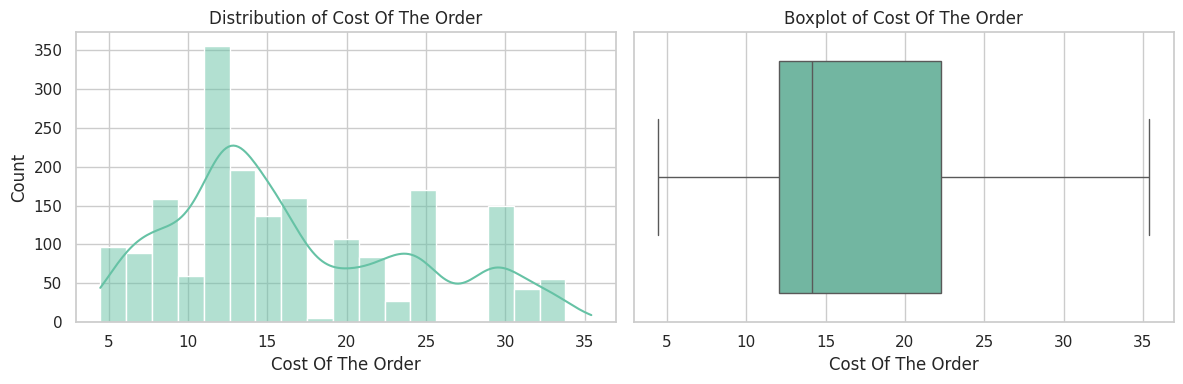

count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64


In [12]:
plot_numeric_distribution(df, 'cost_of_the_order')


Observation - Cost of Order
1. The distribution of the cost of the order appears to be skewed to the right
2. 50% of the values are less than $14.14
3. There are no apparent outliers in the order cost based on the boxplot

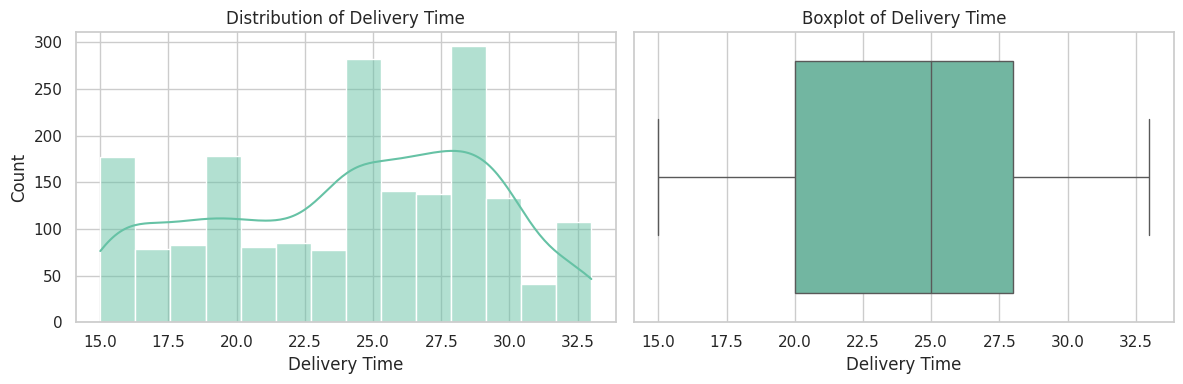

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64


In [13]:
plot_numeric_distribution(df, 'delivery_time')


Observation - Delivery time

1. The distribution of delivery time is roughly symmetrical and appears to be slightly skewed to the left
2. 50% of the delivery time is less than or equal to 25 min
3. There are no apparent outliers in the delivery time based on the boxplot.

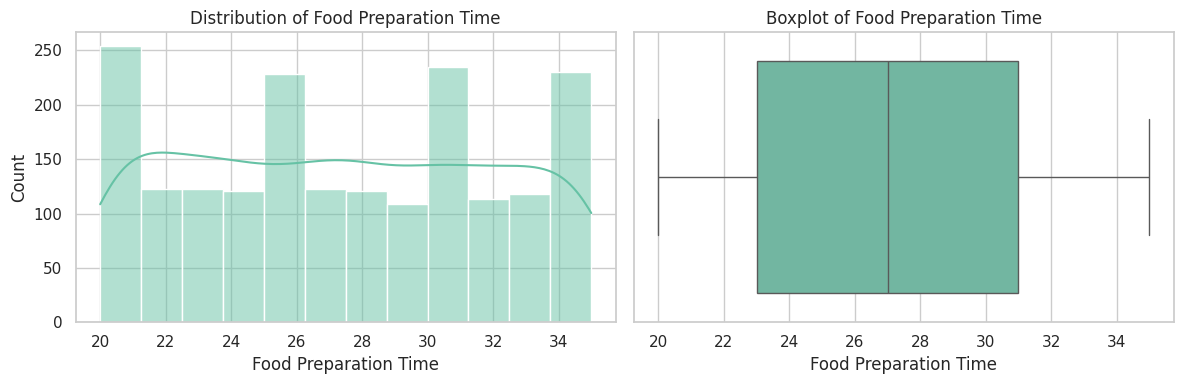

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64


In [14]:
plot_numeric_distribution(df, 'food_preparation_time')


Observation - Food preparation time

1. The distribution of the food preparation time appears to be roughly uniform
2. The average food preparation time is approximately 27.37 minutes.
3. There are no apparent outliers in the food preparation time

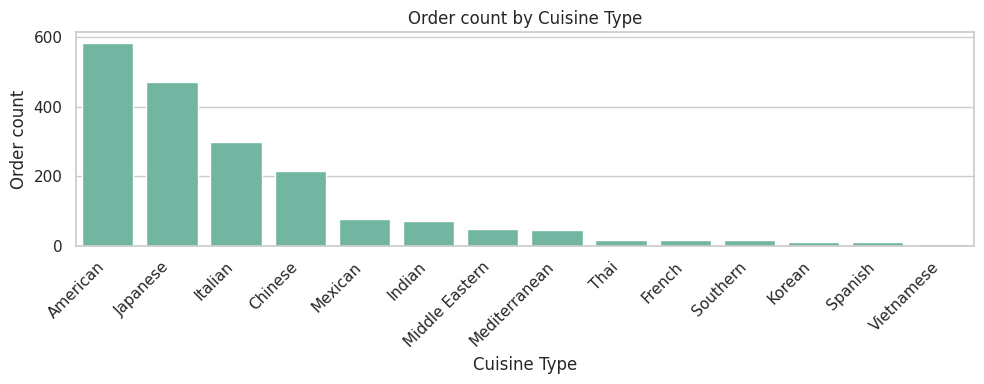

cuisine_type
American          0.3077
Japanese          0.2476
Italian           0.1570
Chinese           0.1133
Mexican           0.0406
Indian            0.0385
Middle Eastern    0.0258
Mediterranean     0.0242
Thai              0.0100
French            0.0095
Southern          0.0090
Korean            0.0068
Spanish           0.0063
Vietnamese        0.0037
Name: proportion, dtype: float64


In [15]:
plot_categorical_summary(df, 'cuisine_type')


Observation - Cuisine type
- There are a total of 1898 restaurants, with maximum number of restaurants serving American cuisine (584; 30.7%)
- 14 different types of cuisines are available to choose from

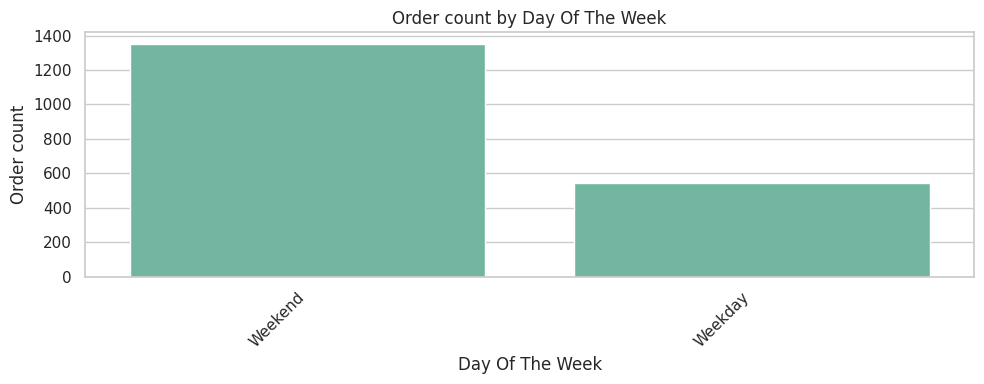

day_of_the_week
Weekend    0.7118
Weekday    0.2882
Name: proportion, dtype: float64


In [16]:
plot_categorical_summary(df, 'day_of_the_week')


Observation - Day of the week

- Over 71% of the orders are placed on the weekends

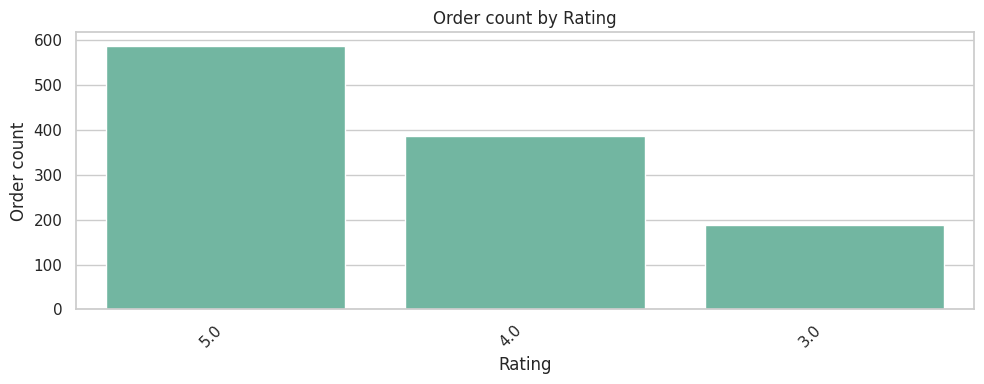

rating
5.0    0.5060
4.0    0.3322
3.0    0.1618
Name: proportion, dtype: float64


In [17]:
plot_categorical_summary(df, 'rating')


Observations - Rating

1. Approximately 38.8% orders do not have a rating
2. Among the rated orders, majority (about 31%) have the highest rating of 5
3. Ratings of 4 and 3 are less frequent, with approximately 20.3% and 9.9% of orders respectively

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [18]:
# Write the code here
# get the top 5 rows with max orders calculated using valuecounts function
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
Following are the top 5 restaurants in terms of orders received:

Shake Shack: 219
The Meatball Shop:	132
Blue Ribbon Sushi:	119
Blue Ribbon Fried Chicken:	96
Parm:	68

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [19]:
# Most popular cuisine among weekend orders
df.loc[df['day_of_the_week'] == 'Weekend', 'cuisine_type'].value_counts().head(1)


,count
cuisine_type,
American,415


#### Observations:
American	415


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [20]:
pct_above_20 = (df['cost_of_the_order'] > 20).mean() * 100
print(f'Share of orders over $20: {pct_above_20:.2f}%')


Share of orders over $20: 29.24%


#### Observations:
29.24% of the orders cost more than $20

### **Question 10**: What is the mean order delivery time? [1 mark]

In [21]:
mean_delivery = df['delivery_time'].mean()
print(f'Mean delivery time: {mean_delivery:.2f} minutes')


Mean delivery time: 24.16 minutes


#### Observations:
Mean order delivery time is 24.16 minutes

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [22]:
# Write the code here

# get order count by customer id, and display the top 3 using head function
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
IDs of top 3 customers with their order counts:
1. 52832	- 13
2. 47440	- 10
3. 83287	- 9


### Multivariate Analysis

In [23]:
# Add a total-time column on a working copy to avoid mutating df
df_with_total_time = df.copy()
df_with_total_time['total_time'] = (
    df_with_total_time['food_preparation_time']
    + df_with_total_time['delivery_time']
)


In [24]:
# Count the cuisines for orders with a missing rating
cuisines_with_null_ratings = (
    df.loc[df['rating'].isna(), 'cuisine_type'].value_counts()
)
print('Cuisines with null ratings (order counts):')
print(cuisines_with_null_ratings)


Cuisines with null ratings (order counts):
cuisine_type
American          216
Japanese          197
Italian           126
Chinese            82
Mexican            29
Indian             23
Middle Eastern     15
Mediterranean      14
Thai               10
French              8
Spanish             6
Korean              4
Southern            4
Vietnamese          2
Name: count, dtype: int64


### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


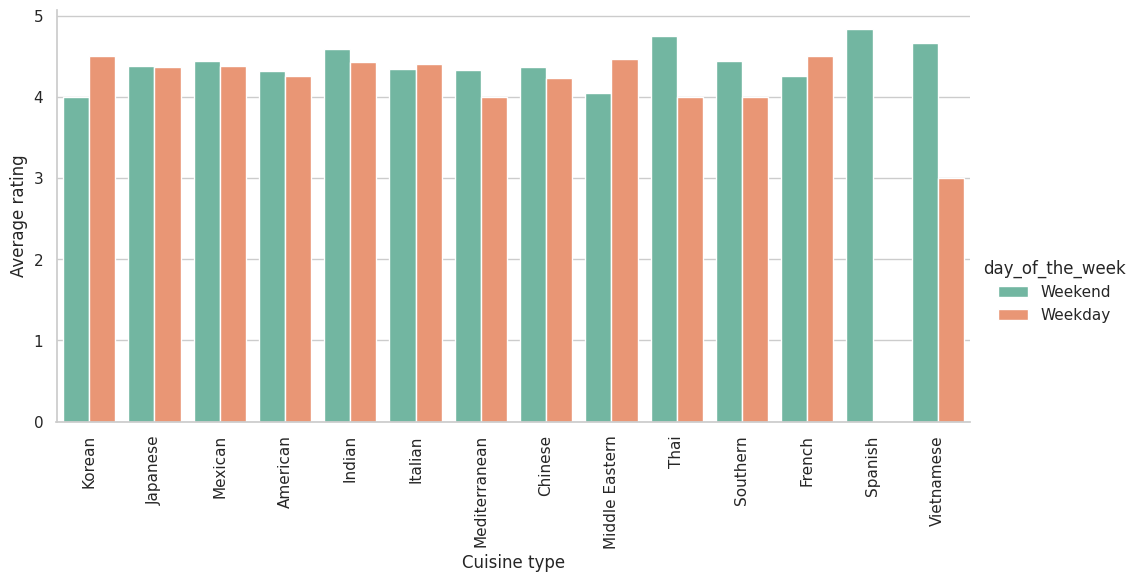

In [25]:
g = sns.catplot(
    data=df_with_total_time,
    x='cuisine_type', y='rating', hue='day_of_the_week',
    kind='bar', errorbar=None, height=5, aspect=2,
)
g.set_xticklabels(rotation=90)
g.set_axis_labels('Cuisine type', 'Average rating')
plt.show()


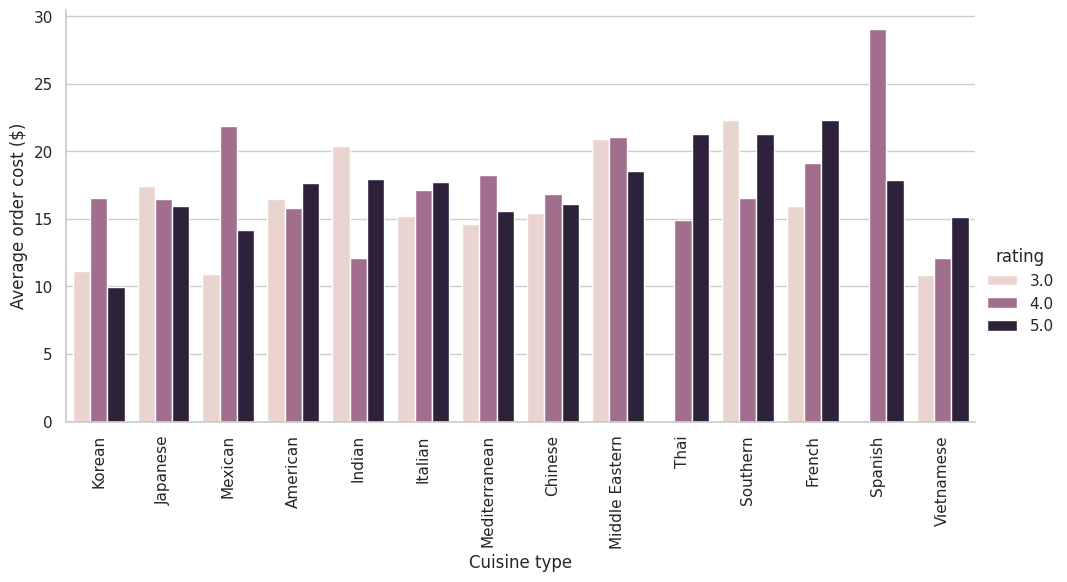

In [26]:
g = sns.catplot(
    data=df_with_total_time,
    x='cuisine_type', y='cost_of_the_order', hue='rating',
    kind='bar', errorbar=None, height=5, aspect=2,
)
g.set_xticklabels(rotation=90)
g.set_axis_labels('Cuisine type', 'Average order cost ($)')
plt.show()


# Key Observations:
1. There is a clear variation in the average cost of orders across different cuisine types. Some cuisines, like French, Spanish, and Italian, appear to have higher average order costs compared to others like Mexican or Southern.
2. Within each cuisine type, the average cost of orders can vary based on the rating. For some cuisines, orders with higher ratings (4 and 5) might have slightly higher average costs than those with lower ratings (3) or no rating ('Not given'). This could suggest that customers are willing to spend a bit more for orders they rate highly, or perhaps higher-cost orders are more likely to receive higher ratings.
3. For most cuisine types, the average cost of orders with 'Not given' ratings seems to fall somewhere in the middle range of the rated orders. It doesn't consistently lean towards the lowest or highest average costs.

Overall, the plot indicates that both cuisine type and customer rating have some influence on the average cost of an order.

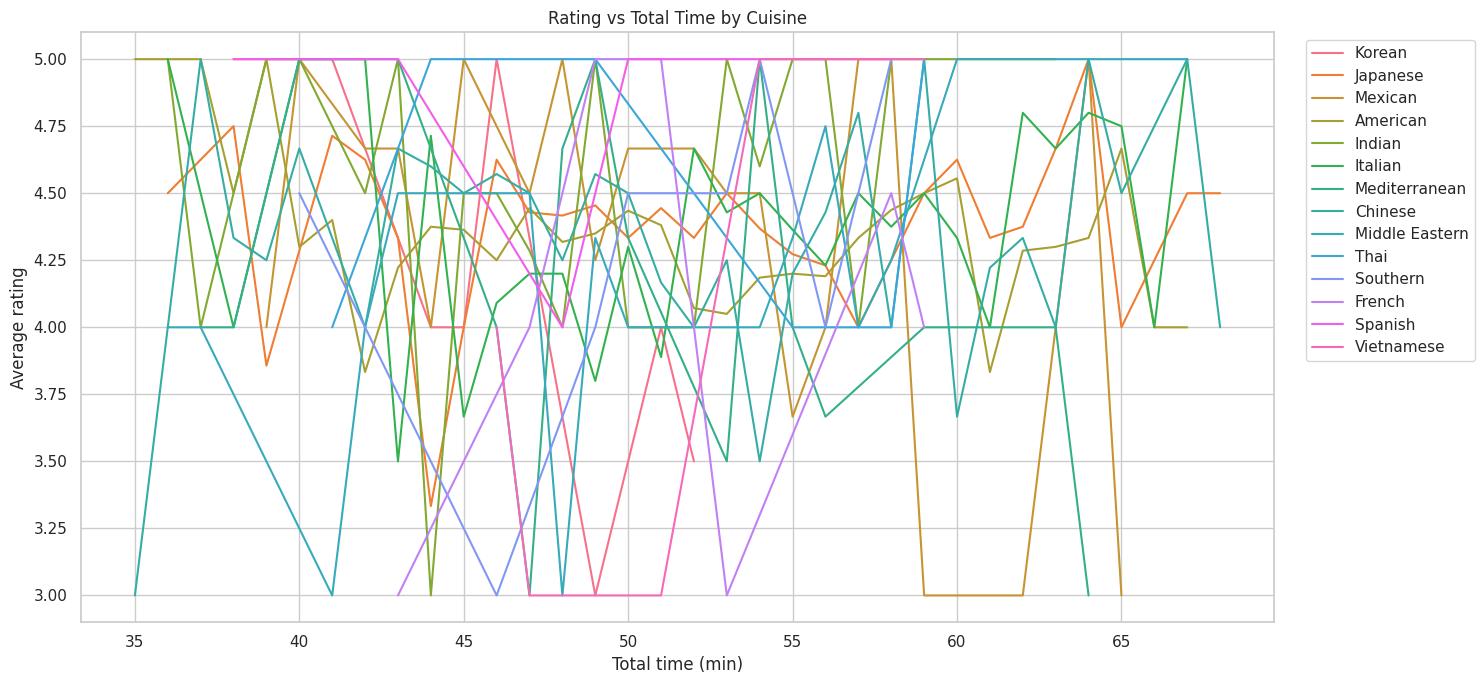

In [27]:
plt.figure(figsize=(15, 7))
sns.lineplot(
    data=df_with_total_time,
    x='total_time', y='rating', hue='cuisine_type',
    estimator=np.mean, errorbar=None,
)
plt.xlabel('Total time (min)')
plt.ylabel('Average rating')
plt.title('Rating vs Total Time by Cuisine')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#Key observations

1. Longer delivery times don't automatically mean worse ratings.
2. Rating patterns are all over the place as delivery times change, which tells us time matters, but it's clearly not the whole story.
3. Several cuisines seem to get their best ratings when total time falls somewhere in the middle - roughly 45-55 minutes. Orders that are either much faster or much slower tend to score a bit lower. Maybe customers have certain expectations baked in, and anything too far outside that sweet spot feels off.
4. Different cuisines behave really differently here. Some show fairly stable ratings regardless of how long things take, while others have much more dramatic swings. It really depends on what type of food we're talking about.

Customer satisfaction clearly depends on more than just how fast the order arrives. Time plays a role, but there're other factors at play

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [28]:
# Restaurants eligible for the promotional offer:
# rating_count > 50 AND average_rating > 4
eligible_restaurants = (
    df.groupby('restaurant_name')
      .agg(
          rating_count=('rating', 'count'),
          average_rating=('rating', 'mean'),
      )
      .query('rating_count > 50 and average_rating > 4')
)
eligible_restaurants


,rating_count,average_rating
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:

restaurant_name		rating_count	average_rating
Blue Ribbon Fried Chicken	64	4.328125
Blue Ribbon Sushi	73	4.219178
Shake Shack	133	4.278195
The Meatball Shop	84	4.511905

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [29]:
# Commission rules:
#   orders >$20 → 25% commission
#   orders >$5 and <=$20 → 15% commission
HIGH_COMMISSION_RATE = 0.25
MID_COMMISSION_RATE = 0.15
HIGH_COST_THRESHOLD = 20
MID_COST_LOWER = 5

high_cost = df.loc[df['cost_of_the_order'] > HIGH_COST_THRESHOLD, 'cost_of_the_order']
mid_cost  = df.loc[
    (df['cost_of_the_order'] > MID_COST_LOWER)
    & (df['cost_of_the_order'] <= HIGH_COST_THRESHOLD),
    'cost_of_the_order',
]

net_revenue = high_cost.sum() * HIGH_COMMISSION_RATE + mid_cost.sum() * MID_COMMISSION_RATE
print(f'Net revenue: ${net_revenue:,.2f}')


Net revenue: $6,166.30


#### Observations:
Net revenue - $6166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [30]:
pct_over_60 = (df_with_total_time['total_time'] > 60).mean() * 100
print(f'Share of orders taking over 60 minutes: {pct_over_60:.2f}%')


Share of orders taking over 60 minutes: 10.54%


#### Observations:
10.54% of orders take more than 60 minutes

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [31]:
# Write the code here

# The code below groups the avg delivery time by day of the week
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
On average, weekday delivery takes about 6 minutes more as compared to weekend

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

#Conclusions

The dataset contains 1,898 orders with 9 columns, with no missing values in the source CSV (though 736 ratings are encoded as `'Not given'` and are converted to NaN for downstream numeric analysis).

The cost of orders is right-skewed, with a majority of orders costing less than $14.14. There are no apparent outliers in order cost.

Delivery time is roughly symmetrical and slightly left-skewed, with an average of approximately 24 minutes and no apparent outliers.

Food preparation time is roughly uniformly distributed, with an average of about 27 minutes and no apparent outliers.

American cuisine is the most popular, followed by Japanese and Italian. There are 14 different cuisine types available.

A significant portion of orders (over 71%) are placed on weekends.

A considerable number of orders (38.8%) are not rated. Among the rated orders, a majority are rated 5. The unrated orders are not randomly distributed — they cluster in the highest-volume cuisines: American (216), Japanese (197), Italian (126), Chinese (82), and Mexican (29) together account for roughly 88% of all unrated orders.

The top 5 restaurants by order count are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

American cuisine is the most popular on weekends.

Approximately 29.24% of orders cost more than $20.

The mean order delivery time is about 24.16 minutes.

The top 3 most frequent customers are IDs 52832 (13 orders), 47440 (10 orders), and 83287 (9 orders).

The net revenue generated by the company across all orders is approximately $6166.30.

About 10.54% of orders take more than 60 minutes total (preparation + delivery).

Mean delivery time is higher on weekdays (approx. 28.34 minutes) compared to weekends (approx. 22.47 minutes).

The multivariate analysis showed no strong linear relationship between total time and rating, with fluctuations observed across different cuisine types. Average order cost varies by cuisine type and can be influenced by rating.

Restaurants eligible for the promotional offer (rating count > 50 and average rating > 4) are Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop.

#Recommendations


Get More Customer Feedback: Nearly 40% of orders aren't getting rated, which means we're missing out on valuable insights. Try incentivizing ratings with small discounts or loyalty points, or send friendly reminders through the app after delivery. **Focus the push on the highest-volume cuisines first** — American, Japanese, and Italian alone account for the bulk of unrated orders, so even a modest rating-completion lift in those segments yields the largest absolute gain in feedback volume.

Look Beyond Delivery Speed: Since faster delivery doesn't automatically mean better ratings, dig into what else matters to customers (e.g., food quality issues, delivery issues, etc.)

Improve the Weekday Slowdown: Deliveries on weekdays take about 6 minutes longer on average. Take a closer look at what's causing the delay and adjust driver schedules or routes accordingly.

There are some clear winners - Shake Shack, Blue Ribbon restaurants, American cuisine. Put more marketing muscle behind these popular spots and consider exclusive deals or featured placements for your top performers.

Reward Your Best Customers: Set up a proper loyalty program or VIP perks to keep them coming back and turn occasional users into regulars.

Tackle the Extreme Delays: About 10% of orders are taking over an hour. Even if it's a small percentage, these are the ones that create the worst experiences. Track down what's going wrong with these orders and fix the issues.

Customize by Cuisine Type: Different food categories behave differently. High-end orders need to match the price with quality. For cuisines where ratings swing based on timing, work on making prep and delivery more consistent.

---